In [44]:
import scipy.io
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

# WTMM
import pyfftw
import matplotlib.pylab as pl
import rasterio as rio
import subprocess
import json
import geojson
# import pandas as pd
import glob
import time
from multiprocessing import Pool
import datetime
from pyproj import Proj
from scipy.interpolate import interp2d

from Xsmurf_functions import *

In [45]:
def read_mat_data(filepath):
    rd = scipy.io.loadmat(filepath) # load the mat file
    PDATA = rd['PDATA']
    TWT = rd['TWT']
    
    return PDATA, TWT

In [100]:
 # set path to the processed mat files
filespath = '/Users/jukesliu/Documents/POSTDOC/snow-radar/ReynoldsMountain/ProcessedApril2025/'
files = os.listdir(filespath)
files.sort()
print(files)

['GPS_all.mat', 'p1_1.mat', 'p1_10.mat', 'p1_11.mat', 'p1_12.mat', 'p1_13.mat', 'p1_14.mat', 'p1_15.mat', 'p1_16.mat', 'p1_17.mat', 'p1_18.mat', 'p1_19.mat', 'p1_2.mat', 'p1_3.mat', 'p1_4.mat', 'p1_5.mat', 'p1_6.mat', 'p1_7.mat', 'p1_8.mat', 'p1_9.mat', 'pdriftzigzag_1.mat', 'pdriftzigzag_10.mat', 'pdriftzigzag_11.mat', 'pdriftzigzag_11_PDATA.mat', 'pdriftzigzag_12.mat', 'pdriftzigzag_13.mat', 'pdriftzigzag_13_PDATA.mat', 'pdriftzigzag_14.mat', 'pdriftzigzag_15.mat', 'pdriftzigzag_15_PDATA.mat', 'pdriftzigzag_2.mat', 'pdriftzigzag_3.mat', 'pdriftzigzag_4.mat', 'pdriftzigzag_5.mat', 'pdriftzigzag_6.mat', 'pdriftzigzag_7.mat', 'pdriftzigzag_8.mat', 'pdriftzigzag_8_PDATA.mat', 'pdriftzigzag_9.mat', 'pt3_1.mat', 'pt3_10.mat', 'pt3_11.mat', 'pt3_12.mat', 'pt3_13.mat', 'pt3_14.mat', 'pt3_15.mat', 'pt3_16.mat', 'pt3_17.mat', 'pt3_18.mat', 'pt3_19.mat', 'pt3_2.mat', 'pt3_20.mat', 'pt3_21.mat', 'pt3_22.mat', 'pt3_23.mat', 'pt3_24.mat', 'pt3_25.mat', 'pt3_26.mat', 'pt3_27.mat', 'pt3_28.mat', 'pt

In [101]:
# read in processed data
[PDATA, TWT] = read_mat_data(filespath+'pdriftzigzag_8_PDATA.mat')
halfidx = PDATA.shape[0]
TWT = TWT[0][halfidx:]
len(TWT)

8192

In [102]:
np.diff(TWT)

array([1.14186605e-11, 1.14186605e-11, 1.14186605e-11, ...,
       1.14186605e-11, 1.14186605e-11, 1.14186605e-11])

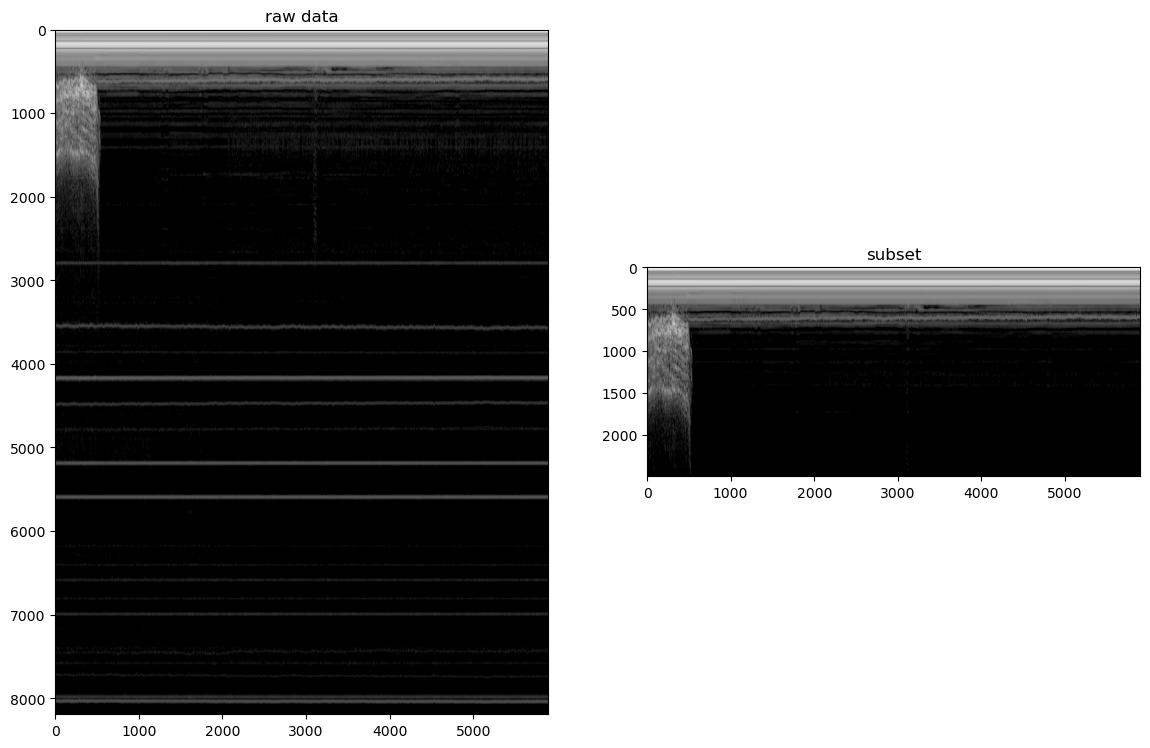

In [103]:
# subset the data
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(14,14)) # initialize a figure to show before and after
ax1.imshow(PDATA, vmin=np.percentile(PDATA,50), vmax=np.percentile(PDATA,100), cmap='Greys_r')
ax1.set_title("raw data")

PDATA = PDATA[:2500,:]# keep only upper portion of the data

ax2.imshow(PDATA, vmin=np.percentile(PDATA,50), vmax=np.percentile(PDATA,100), cmap='Greys_r')
ax2.set_title("subset")
plt.show()

In [90]:
def apply_range_gain(RADARGRAM):
    ylen = RADARGRAM.shape[0] # grab the ydimension
    yvec = np.arange(1,ylen+1) # create a vector starting at 1 through the maximum index (ylen)

    # different shapes of range multiplier vector:
    # range_multiplier = np.array(1/(yvec**2))
    # range_multiplier = np.array(1/np.sqrt(yvec))
    # range_multiplier = np.array(np.flip(yvec)/np.max(yvec)) # linear
    range_multiplier = np.array(np.log(np.flip(yvec))) # logarithmic
    plt.plot(range_multiplier); plt.title('range multiplier')
    plt.show()

    fig, (ax1,ax2) = plt.subplots(1,2,figsize=(14,14)) # initialize a figure to show before and after
    ax1.imshow(RADARGRAM, vmin=np.percentile(RADARGRAM,50), vmax=np.percentile(RADARGRAM,100), cmap='Greys_r')
    ax1.set_title("before range gain correction")

    RADARGRAM = RADARGRAM * np.transpose([range_multiplier]) # CORRECTION

    # show after range gain correction
    ax2.imshow(RADARGRAM, vmin=np.percentile(RADARGRAM,50), vmax=np.percentile(RADARGRAM,98), cmap='Greys_r')
    ax2.set_title("after range gain correction")
    plt.show()

    return RADARGRAM

In [91]:
# radargram = apply_range_gain(PDATA)

In [92]:
def remove_flats(RADARGRAM, minval, noise_thresh=1.0):
    fig, (ax1,ax2) = plt.subplots(1,2,figsize=(14,14)) # initialize a figure to show before and after
    ax1.imshow(RADARGRAM, vmin=np.percentile(RADARGRAM,50), vmax=np.percentile(RADARGRAM,98), cmap='Greys_r')
    ax1.set_title("before removing flat reflectors")
    
    yidxs = np.arange(0,RADARGRAM.shape[0]) # rows
    for yidx in yidxs:
        row = RADARGRAM[yidx,:] # grab the row
        # plt.plot(row); plt.show() # visualize (optional)

        # if the full noise range is less than the threshold, remove the reflector 
        if (np.nanmax(row) - np.nanmin(row)) <= noise_thresh: # inclusive noise threshold
            RADARGRAM[yidx,:] = np.ones(RADARGRAM.shape[1])*minval # replace original values with the minval in the radargram
    # show before and after
    ax2.imshow(RADARGRAM, vmin=np.percentile(RADARGRAM,50), vmax=np.percentile(RADARGRAM,98), cmap='Greys_r')
    ax2.set_title("after removing flat reflectors")
    plt.show()

    return RADARGRAM

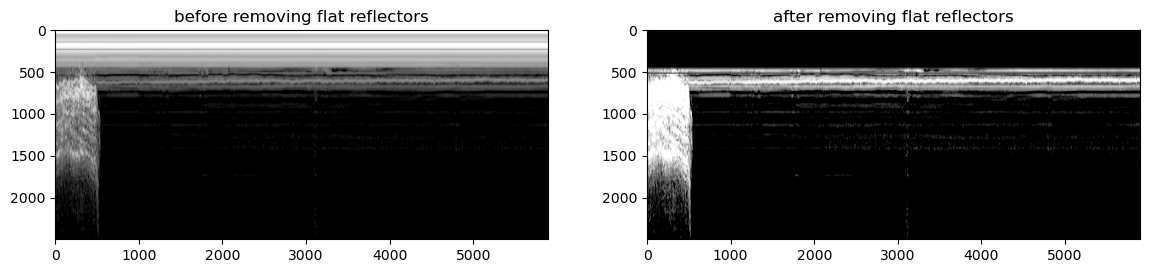

In [93]:
rd1 = remove_flats(PDATA, np.percentile(PDATA,50), np.std(PDATA)*2) # use the std of the radargram as the noise threshold
# use 2-4x STD

In [111]:
# rd1 = remove_flats(radargram, np.percentile(radargram,50), np.std(radargram)*3) # use the std of the radargram as the noise threshold

In [95]:
# # save the output as an image
# # plt.savefig('/Users/jukesliu/Documents/POSTDOC/snow-radar/Reynolds_testimg.png',dpi=300)
# # cv2.imwrite('/Users/jukesliu/Documents/POSTDOC/snow-radar/Reynolds_testimg.jpg', PDATA) # save as jpeg for testing
# from PIL import Image

# # scipy.misc.imsave('/Users/jukesliu/Documents/POSTDOC/snow-radar/Reynolds_testimg_corrected.jpg', rd1)
# # scipy.misc.toimage(rd1).save('/Users/jukesliu/Documents/POSTDOC/snow-radar/Reynolds_testimg_corrected.tif')
# im = Image.fromarray(rd1)
# im.save("/Users/jukesliu/Documents/POSTDOC/snow-radar/Reynolds_testimg_corrected.tif")

In [94]:
# save as displayed
rd1[rd1 < np.percentile(rd1,50)] = np.percentile(rd1,50)
rd1[rd1 > np.percentile(rd1,98)] = np.percentile(rd1,50)

In [95]:
rd_norm = rd1-np.percentile(rd1,50) # normalize

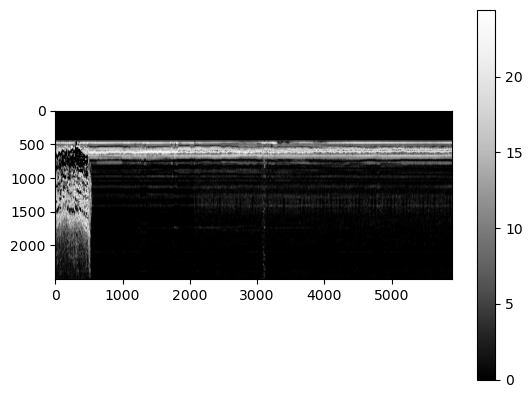

In [96]:
plt.imshow(rd_norm,cmap='Greys_r')
plt.colorbar()
plt.show()

In [23]:
# # save normalized array
# im = Image.fromarray(rd_norm)
# im.save("/Users/jukesliu/Documents/POSTDOC/snow-radar/Reynolds_testimg_corrected.tif")

# Try wavelet parameters

In [24]:
# # def radarFitThresh(thresholds):
# def wtmmradar(radargram, TWT, wtmm_scale, size_thresh, mod_thresh_multiplier):
#     # Function to fit radar depths using the 2d wtmm
#     # By Jukes Liu (jukes.liu@gmail.com)
#     # Based off of code written by HP Marshall
#     # INPUTS:
#     # - radargram as 2D array
#     # - wtmm_scale = size of wavelet transform (units: gridcells)
#     # - size_thresh = min. length of wtmm delineation to filter by (units: gridcells)
#     # - mod_thresh_multiplier = multiply the mean modulus of the entire image by this scalar to filter out low-gradient lines
#     # OUTPUTS:
#     # - x_idxs = array of x-locations for the radar picks
#     # - surf_idxs = array of indices of snow surface picks
#     # - ground_idxs = array of indices of ground picks
#     # - depths = array of depths

#     x_idxs = []
#     surf_idxs = []
#     ground_idxs = []
#     depths = [] 

#     # Run the WTMM
#     # print(wtmm_scale)
#     [dx,dy,mm,m,a] = wtmm2d_v2(radargram,'gauss',wtmm_scale)  
    
#     # # Visualize outputs from wtmm2d:
#     # fig, axs = plt.subplots(2,3,figsize=(15,10))
#     # axs[0,0].imshow(dx, aspect='equal', cmap = 'gray', interpolation='none'); axs[0,0].set_title('dx') # x gradient
#     # axs[0,1].imshow(dy, aspect='equal', cmap = 'gray', interpolation='none'); axs[0,1].set_title('dy') # y gradient
#     # axs[0,2].imshow(a, aspect='equal', cmap = 'gray', interpolation='none'); axs[0,2].set_title('a') # argument            
#     # axs[1,0].imshow(mm, aspect='equal', cmap = 'gray', interpolation='none', vmin = np.min(mm), vmax = np.max(m)); 
#     # axs[1,0].set_title('mm') # modulus maxima (interpolated)
#     # axs[1,1].imshow(m, aspect='equal', cmap = 'gray', interpolation='none',vmin = np.min(mm), vmax = np.max(m));
#     # axs[1,1].set_title('m') # modulus
#     # axs[-1,-1].axis('off')
#     # plt.show()

#     # Chain the traces
#     cmm = wtmmchains(mm,a,0,wtmm_scale,3) # chain at a specified scale (UNMASKED)

#     # Filter chains based on size threshold
#     cmm_passed = []
#     mods = []
#     for j in range(0, len(cmm)):
#         if cmm[j].size > size_thresh: # adjust this condition to threshold
#             cmm_passed.append(cmm[j])
#             mods.append(cmm[j].linemeanmod) # collect mod information

#     # Filter again based on mods
#     cmm_passed_2 = []
#     # Filter chains based on size and mod threshold
#     for k in range(0, len(cmm_passed)):
#         if cmm_passed[k].linemeanmod > np.nanmean(mods)*mod_thresh_multiplier:
#             cmm_passed_2.append(cmm_passed[k])

#     # STRATEGY TO GRAB FIRST RETURNS FROM CHAINS
#     xs = []; ys = [] # grab all chain coordinates
#     for n in range(0, len(cmm_passed_2)):
#         xs.extend(cmm_passed_2[n].ix); ys.extend(cmm_passed_2[n].iy)
#     chain_coords = list(zip(xs,ys)); chain_coords.sort() # sort by xs
#     [xs,ys] = zip(*chain_coords)
#     xs = list(xs); ys = list(ys)
    
#     # PLOT RESULTS:
#     fig,ax = plt.subplots(1,figsize=(15,5))
#     ax.imshow(np.array(radargram),cmap='gray')
#     ax.set_xlim([0, np.array(radargram).shape[1]])
#     ax.set_ylim([0, np.array(radargram).shape[0]])
#     ax.invert_yaxis(); ax.set_aspect('equal')
    
#     # FOR EACH COLUMN GRAB FIRST AND SECOND RETURN AND SUBTRACT (ONLY IF THERE ARE AT LEAST TWO), WINDOW REMOVED
#     for x_idx in range(0,radargram.shape[1]): 
#         coord_idxs = np.where(xs == x_idx)
#         # if there are at least 2 crossings at the x
#         if len(coord_idxs[0]) > 2:

#             print(xs[coord_idxs[0]])
#             cxs = []; cys = []
#             for idx in coord_idxs[0]:
#                 cxs.append(xs[idx]); cys.append(ys[idx]) # grab the x and y coordinates

#             # grab the first pair of ys that is > 1 apart
#             diff_idxs = np.where(np.diff(cys) > 1)[0]
#             if len(diff_idxs) > 0:
#                 diff_first = diff_idxs[0]
#                 diff_last = diff_idxs[-1]
#                 Isurf = int(cys[diff_first]) # grab the returns
#                 # Iground = int(cys[diff_first+1]) # grab the paired return
#                 Iground = int(cys[diff_last]) # grab the last return
#                 depth = (TWT[Iground]-TWT[Isurf])*2.25e10 # calculate depth from TWTs
#                 # print(depth)
#                 ax.plot(x, Isurf, 'b.')# plot the surface return
#                 ax.plot(x, Iground, 'r.')# plot the ground return
#                 depths.append(depth)
#             else:
#                 depths.append(np.NaN)
    
#     plt.tight_layout()
#     ax.legend(['surface','ground'])
#     plt.savefig('/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/wtmm_radar_'+str(wtmm_scale)+'scale_'+str(size_thresh)+'sizethresh.jpg',dpi=200)
#     plt.show()

#     return x_idxs, surf_idxs, ground_idxs, depths

In [25]:
# [x_idxs, surf_idxs, ground_idxs, depths] = wtmmradar(rd_norm, TWT, 400, 80, 1.2)

In [97]:
radargram = rd_norm
wtmm_scale = 400
size_thresh = 100
mod_thresh_multiplier = 1.2

x_idxs = []
surf_idxs = []
ground_idxs = []
depths = [] 

# Run the WTMM
# print(wtmm_scale)
[dx,dy,mm,m,a] = wtmm2d_v2(radargram,'gauss',wtmm_scale)  

# # Visualize outputs from wtmm2d:
# fig, axs = plt.subplots(2,3,figsize=(15,10))
# axs[0,0].imshow(dx, aspect='equal', cmap = 'gray', interpolation='none'); axs[0,0].set_title('dx') # x gradient
# axs[0,1].imshow(dy, aspect='equal', cmap = 'gray', interpolation='none'); axs[0,1].set_title('dy') # y gradient
# axs[0,2].imshow(a, aspect='equal', cmap = 'gray', interpolation='none'); axs[0,2].set_title('a') # argument            
# axs[1,0].imshow(mm, aspect='equal', cmap = 'gray', interpolation='none', vmin = np.min(mm), vmax = np.max(m)); 
# axs[1,0].set_title('mm') # modulus maxima (interpolated)
# axs[1,1].imshow(m, aspect='equal', cmap = 'gray', interpolation='none',vmin = np.min(mm), vmax = np.max(m));
# axs[1,1].set_title('m') # modulus
# axs[-1,-1].axis('off')
# plt.show()

# Chain the traces
cmm = wtmmchains(mm,a,0,wtmm_scale,wtmm_scale/4) # chain at a specified scale (UNMASKED)

# Filter chains based on size threshold
cmm_passed = []
mods = []
for j in range(0, len(cmm)):
    if cmm[j].size > size_thresh: # adjust this condition to threshold
        cmm_passed.append(cmm[j])
        mods.append(cmm[j].linemeanmod) # collect mod information

# Filter again based on mods
cmm_passed_2 = []
# Filter chains based on size and mod threshold
for k in range(0, len(cmm_passed)):
       if cmm_passed[k].linemeanmod > np.nanmean(mods)*mod_thresh_multiplier:
        cmm_passed_2.append(cmm_passed[k])

# STRATEGY TO GRAB FIRST RETURNS FROM CHAINS
xs = []; ys = [] # grab all chain coordinates
for n in range(0, len(cmm_passed_2)):
    xs.extend(cmm_passed_2[n].ix); ys.extend(cmm_passed_2[n].iy)
chain_coords = list(zip(xs,ys)); chain_coords.sort() # sort by xs
[xs,ys] = zip(*chain_coords)
xs = list(xs); ys = list(ys)

/Users/jukesliu/Documents/GitHub/snow-radar/Xsmurf_functions.py:852: RuntimeWarning: invalid value encountered in divide
  dx_norm = np.divide(dx,m)
/Users/jukesliu/Documents/GitHub/snow-radar/Xsmurf_functions.py:853: RuntimeWarning: invalid value encountered in divide
  dy_norm = np.divide(dy,m)


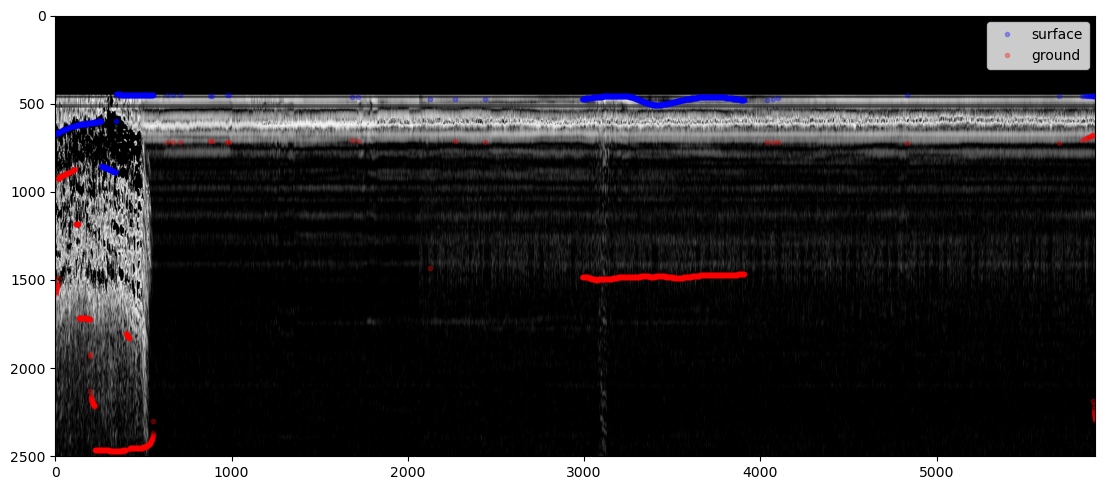

In [98]:
# PLOT RESULTS:
a=0.3
fig,ax = plt.subplots(1,figsize=(15,5))
ax.imshow(np.array(radargram),cmap='gray')
ax.set_xlim([0, np.array(radargram).shape[1]])
ax.set_ylim([0, np.array(radargram).shape[0]])
ax.invert_yaxis(); ax.set_aspect('equal')

# FOR EACH COLUMN GRAB FIRST AND SECOND RETURN AND SUBTRACT (ONLY IF THERE ARE AT LEAST TWO), WINDOW REMOVED
for x_idx in range(0,radargram.shape[1]): 
    coord_idxs = np.where(np.array(xs) == x_idx)
    coord_idxs = coord_idxs[0]
    # if there are at least 2 crossings at the x
    if len(coord_idxs) > 2:
        cxs = []; cys = []
        for idx in coord_idxs:
            cxs.append(xs[idx]); cys.append(ys[idx]) # grab the x and y coordinates

        # grab the first pair of ys that is > 1 apart
        diff_idxs = np.where(np.diff(cys) > 1)[0]
        if len(diff_idxs) > 0:
            diff_first = diff_idxs[0]
            diff_last = diff_idxs[-1]+1
            Isurf = int(cys[diff_first]) # grab the returns
            # Iground = int(cys[diff_first+1]) # grab the paired return
            Iground = int(cys[diff_last]) # grab the last return
            depth = (TWT[Iground]-TWT[Isurf])*2.25e10 # calculate depth from TWTs
            # print(depth)
            ax.plot(x_idx, Isurf, 'b.', alpha=a)# plot the surface return
            ax.plot(x_idx, Iground, 'r.', alpha=a)# plot the ground return
            depths.append(depth)
        else:
            depths.append(np.NaN)

plt.tight_layout()
ax.legend(['surface','ground'])
plt.savefig('/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/wtmm_radar_'+str(wtmm_scale)+'scale_'+str(size_thresh)+'sizethresh.jpg',dpi=200)
plt.show()